<a href="https://colab.research.google.com/github/whateveri/models/blob/stable_diffusion_img2img_partial_structure/stable_diffusion_img2img_partial_structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import PIL.Image
from transformers import CLIPImageProcessor, CLIPTokenizer,CLIPTextModel, CLIPVisionModelWithProjection


device = "cuda" if torch.cuda.is_available() else "mps"



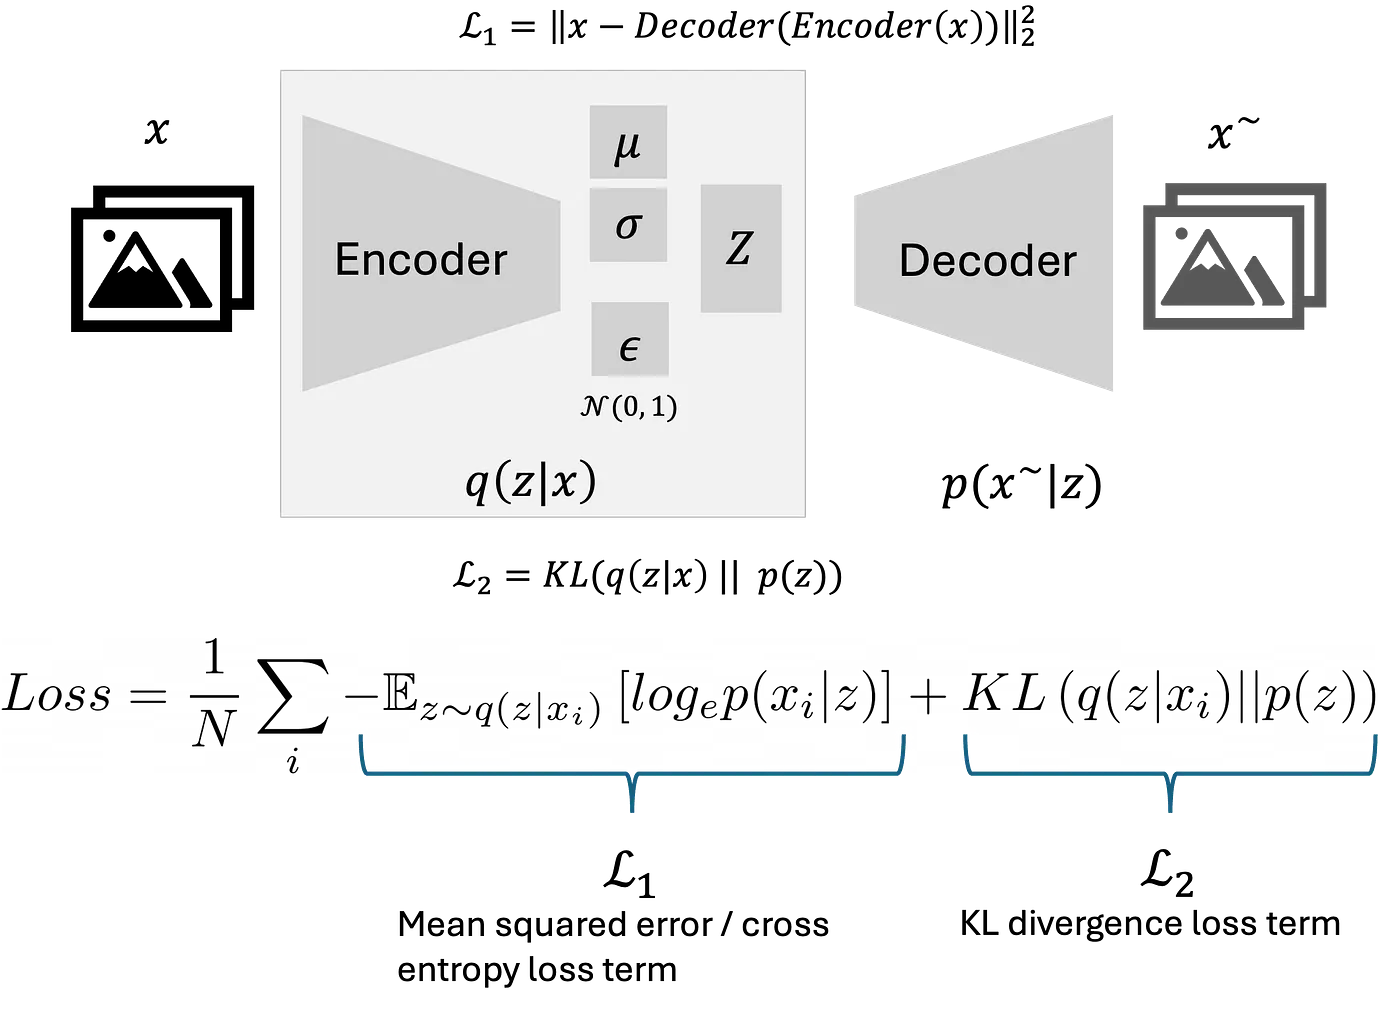

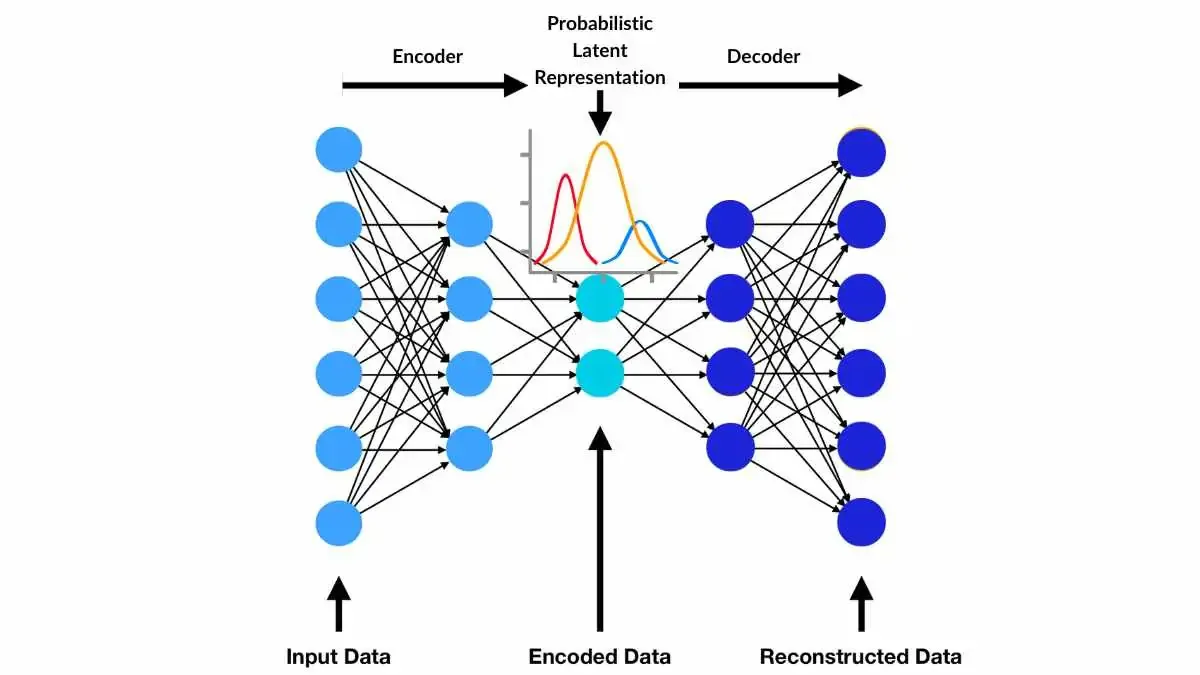

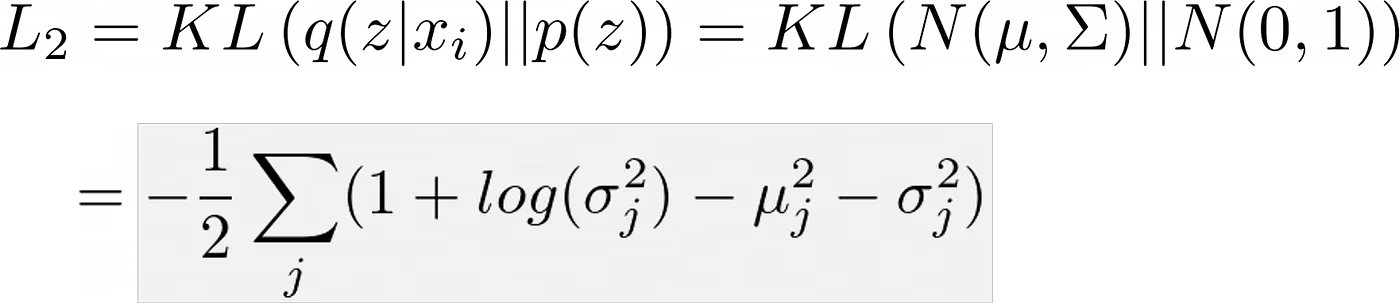

In [ ]:
# upsample

class UpSample(nn.Module):
    def __init__(self,in_channels,
                 out_channels,
                 use_conv=False,
                 use_conv_transpose=False,
                 padding=1,
                 name="conv",
                 kernel_size=None,
                 bias=True,

                 interpolate=True
                 ) :
        super().__init__()
        self.in_channels=in_channels
        self.out_channels=out_channels or in_channels
        self.use_conv=use_conv
        self.use_conv_transpose=use_conv_transpose
        self.name=name
        self.interpolate=interpolate

        self.norm=None

        conv=None
        if use_conv_transpose: #get: h*2,w*2
            if kernel_size is None:
                kernel_size=4
            conv=nn.ConvTranspose2d(in_channels=in_channels,
                                out_channels=self.out_channels,
                                kernel_size=kernel_size,
                                stride=2,
                                padding=padding,
                                bias=bias
                                )
        elif use_conv: #get:h,w not changed
            if kernel_size is None:
                kernel_size=3
            conv=nn.Conv2d(in_channels=in_channels,
                           out_channels=self.out_channels,
                           kernel_size=kernel_size,
                           #stride=1
                           padding=padding,
                           bias=bias
                           )
        self.conv=conv
        if name!="conv":
            self.Conv2d_0=conv





    def forward(self,hidden_states,output_size=None):
        assert self.hidden_states[1] == self.in_channels

        if self.use_conv_transpose:
            return self.conv(hidden_states)

        dtype=hidden_states.dtype


        if hidden_states.shape[0] >=64:
            hidden_states.contiguous()
        scale_factor = (
                2 if output_size is None else max([f / s for f, s in zip(output_size, hidden_states.shape[-2:])])
            )

        if hidden_states.numel() * scale_factor > pow(2, 31):
                hidden_states = hidden_states.contiguous()

        if output_size is None:
            hidden_states=nn.functional.interpolate(hidden_states,
                                                  scale_factor=2.0,
                                                  mode="nearest")
        else:
            hidden_states=nn.functional.interpolate(hidden_states,
                                                  size=output_size,
                                                  mode="nearest")

        if self.use_conv:
            hidden_states=self.conv(hidden_states)

        else:
            hidden_states=self.Conv2d_0(hidden_states)

        return hidden_states


#downsample

class DownSample(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels=None,
                 use_conv=False,

                 padding=1,
                 name="conv",
                 kernal_size=3,
                 bias=True

                 ) -> None:
        super().__init__()
        self.in_channels=in_channels,
        self.output_channels=out_channels or in_channels
        stride=2
        self.use_conv=use_conv
        self.padding=padding
        self.name=name

        assert self.in_channels == self.output_channels

        if use_conv:
            conv=nn.Conv2d(self.in_channels,
                           self.output_channel,
                           kernel_size=kernal_size,
                           stride=stride,
                           padding=padding,
                           bias=bias
                           )
        else:
            assert self.in_channels == self.output_channels

            conv=nn.AvgPool2d(kernel_size=stride,stride=stride)

        if name=="conv":
            self.Conv2d_0=conv
            self.conv=conv
        elif name=="Conv2d_0":
            self.conv=conv
        else:
            self.conv=conv


    def forward(self,hidden_states,output_size):
        assert hidden_states.shape[0] == self.in_channels

        if self.use_conv and self.padding == 0:
            pad=(0,1,0,1)
            hidden_states=nn.functional.pad(hidden_states,pad=pad,mode="constant",value=0)
        assert hidden_states.shape[0] == self.in_channels


        hidden_states=self.conv(hidden_states)
        return hidden_states







In [ ]:
# ResnetBlock

class ResnetBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels=None,
                 drop_out=0.0,
                 temb_channels=512,
                 conv_shortcut=False,
                 groups=32,
                 groups_out=None,
                 pre_norm=True,
                 eps=1e-6,
                 #activation=silu
                 skip_time_act=False,
                 time_embedding_norm="default", #default, scale_shift
                 output_scale_factor=1.0,
                 use_in_shortcut=None,
                 up=False,
                 down=False,
                 conv_shortcut_bias=True,
                 conv_out_channels=None


                 ) -> None:
        super().__init__()
        self.in_channels=in_channels
        out_channels=in_channels if out_channels is None else out_channels
        self.output_scale_factor=output_scale_factor
        self.pre_norm=pre_norm
        self.out_channels=out_channels
        self.use_conv_shortcut=conv_shortcut
        self.up=up
        self.down=down


        self.skip_time_act=skip_time_act
        self.time_embedding_norm=time_embedding_norm


        if torch.groups_out is None:
            groups_out=groups

        self.norm1=nn.GroupNorm(num_groups=groups,
                                num_channels=in_channels,
                                eps=eps,
                                affine=True)
        self.conv1=nn.Conv2d(in_channels=in_channels,
                             out_channels=out_channels,
                             kernel_size=3,
                             stride=1,
                             padding=1

                            )
        if temb_channels is not None:
            if self.time_embedding_norm == "default":
                self.time_embed_proj=nn.Linear(in_features=temb_channels,
                                               out_features=out_channels
                                               )

            elif self.time_embedding_norm=="scale_shift":
                self.time_embed_proj=nn.Linear(in_features=temb_channels,
                                               out_features=2*out_channels)
            else:
                raise ValueError("unknoen time_embedding_norm")

        else:
            self.time_embed_proj=None

        self.norm2=nn.GroupNorm(num_groups=groups_out,
                                num_channels=out_channels,
                                eps=eps,
                                affine=True)
        self.drop_out=nn.Dropout(drop_out)
        conv_out_channels= conv_out_channels or out_channels

        self.conv2=nn.Conv2d(in_channels=out_channels,
                             out_channels=conv_out_channels,
                             kernel_size=3,
                             stride=1,
                             padding=1)
        self.activation=nn.SiLU()

        self.upsample=self.downsample=None
        if self.up:
            self.up_sample=UpSample(in_channels=in_channels)
        elif self.down:
            self.down_sample=DownSample(in_channels=in_channels,use_conv=False)

        self.use_in_shortcut=self.in_channels != conv_out_channels if use_in_shortcut is None else use_in_shortcut

        self.conv_shorcut=None
        if self.use_in_shortcut:
            self.conv_shorcut=nn.Conv2d(
                in_channels=in_channels,
                out_channels=conv_out_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=conv_shortcut_bias
            )




    def forward(self,x,temb):
      #requires temb shape:[B,2*C], x shape:[B,C,H,W]
        hidden_states=x
        hidden_states=self.norm1(hidden_states)
        hidden_states=self.activation(hidden_states)

        if self.up_sample is not None:
            if hidden_states.shape[0]>=64:
                x=x.contiguous()
                hidden_states=hidden_states.contiguous()
            x=self.up_sample(x)
            hidden_states=self.up_sample(hidden_states)
        elif self.down_sample is not None:
            x=self.down_sample(x)
            hidden_states=self.down_sample(hidden_states)
        hidden_states=self.conv1(hidden_states)

        if self.time_embed_proj is not None:
            if not self.skip_time_act:
                temb=self.activation(temb)
            temb=self.time_embed_proj(temb)[:,:,None,None]

        if self.time_embedding_norm == "default":
            if temb is not None:
                hidden_states=hidden_states + temb
            hidden_states=self.norm2(hidden_states)

        elif self.time_embedding_norm == "scale_shift":
            if temb is None:
                raise ValueError(f'temb should not be None when choosing{self.time_embedding_norm} mode')
            time_scale,time_shift=torch.chunk(temb,2,dim=1)
            hidden_states=self.norm2(hidden_states)
            hidden_states==hidden_states * (1+ time_scale) + time_shift

        else:
            hidden_states=self.norm2(hidden_states)

        hidden_states=self.activation(hidden_states)
        hidden_states=self.drop_out(hidden_states)
        hidden_states=self.conv2(hidden_states)

        if self.conv_shorcut is not None:
            x=self.conv_shorcut(x.contiguous())

        result= (x + hidden_states) / self.output_scale_factor
        return result















In [ ]:
# UnetMidBlock2D witout attention

class UnetMidBlock2D(nn.Module):
    def __init__(self,
                 in_channels,
                 temb_channels,
                 dropout=0.0,
                 num_layers=1,
                 resnet_eps=1e-6,
                 #resnet_time_scale_shift="default" ,#default, spacial
                 #resnet_norm="silu"
                 resnet_groups=32,
                 attn_group=None,
                 resnet_pre_norm=True,
                 add_attention=False,
                 attention_dim=1,
                 output_scale_factor=1.0

                 ) :
        super().__init__()
        resnet_groups=resnet_groups if resnet_groups is not None else min(in_channels //4 , 32)
        self.add_attention=add_attention

        attn_group=resnet_groups #always choose default resnet_time_scale_shift

        resnet=[
            ResnetBlock(in_channels=in_channels,
                        out_channels=in_channels,
                        temb_channels=temb_channels,
                        eps=resnet_eps,
                        groups=resnet_groups,
                        drop_out=dropout,
                        output_scale_factor=output_scale_factor,
                        pre_norm=resnet_pre_norm)
        ]
        attentions=[]



        for _ in range(num_layers):
            attentions.append(None)

            resnet.append(
                ResnetBlock(in_channels=in_channels,
                        out_channels=in_channels,
                        temb_channels=temb_channels,
                        eps=resnet_eps,
                        groups=resnet_groups,
                        drop_out=dropout,
                        output_scale_factor=output_scale_factor,
                        pre_norm=resnet_pre_norm)

            )
        self.attentions=nn.ModuleList(attentions)
        self.resnets=nn.ModuleList(resnet)


    def forward(self,hidden_states, temb):
        hidden_states=self.resnets[0](hidden_states,temb)

        for attn, resnet in zip(self.attentions,self.resnets[1:]):
            if attn is not None:
                hidden_states=attn(hidden_states,temb)
            else:
                hidden_states=resnet(hidden_states,temb)
        return hidden_states




In [ ]:
# DownSamping model

class DownEncoderBlock2D(nn.Module):
    def __init__(self, in_channels,
                 out_channels,
                 drop_out=0.0,
                 num_layers=1,
                 resnet_eps: float = 1e-6,
                 resnet_time_scale_shift: str = "default",
                 #resnet_act_fn: str = "swish",
                 resnet_groups: int = 32,
                 resnet_pre_norm: bool = True,
                 output_scale_factor=1.0,
                 add_downsampling=True,
                 downsample_padding=1
                 ) :
        super().__init__()

        resnet=[]

        for i in range(num_layers):
            in_channels=in_channels if i==0 else out_channels
            resnet.append(
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    temb_channels=None,
                    eps=resnet_eps,
                    groups=resnet_groups,
                    drop_out=drop_out,
                    time_embedding_norm=resnet_time_scale_shift,
                    output_scale_factor=output_scale_factor,
                    pre_norm=resnet_pre_norm

                )
            )
        self.resnet=nn.ModuleList(resnet)

        if add_downsampling:
            self.downsamplers=nn.ModuleList([
                DownSample(in_channels= out_channels,
                           out_channels=out_channels,
                           use_conv=True,
                           padding=downsample_padding,
                           name="op")
            ])
        else:
            self.downsamplers=None

    def forward(self,hidden_states):
        for resnet in self.resnet:
            hidden_states=resnet(hidden_states,temb=None)

        if self.downsamplers is not None:
            for downsampler in self.downsamplers:
                hidden_states=downsampler(hidden_states)

        return hidden_states




In [ ]:
class UpDecoderBlock2D(nn.Module):
     def __init__(self,
                  in_channels,
                  out_channels,
                  resolution_idx=None,
                 drop_out=0.0,
                 num_layers=1,
                 resnet_eps: float = 1e-6,
                 resnet_time_scale_shift: str = "default",
                 #resnet_act_fn: str = "swish",
                 resnet_groups: int = 32,
                 resnet_pre_norm: bool = True,
                 output_scale_factor=1.0,
                 add_upsampling=True,
                  temb_channels=None
                  ) :
         super().__init__()

         resnet=[]

         for i in range(num_layers):
            input_channels=in_channels if i==0 else out_channels

            resnet.append(
                ResnetBlock(
                    in_channels=input_channels,
                    out_channels=out_channels,
                    temb_channels=temb_channels,
                    eps=resnet_eps,
                    groups=resnet_groups,
                    drop_out=drop_out,
                    time_embedding_norm=resnet_time_scale_shift,
                    output_scale_factor=output_scale_factor,
                    pre_norm=resnet_pre_norm

                )
            )
         self.resnets=nn.ModuleList(resnet)

         if add_upsampling:
            self.up_sampler=nn.ModuleList([UpSample(in_channels=out_channels,
                                                   out_channels=out_channels,
                                                   use_conv=True
                                                   )])
         else:
            self.up_sampler=None

         self.resolution_idx=resolution_idx


     def forward(self,hidden_states,temb):
         for resnet in self.resnets:

             hidden_states=resnet(hidden_states,temb=temb)

         if self.up_sampler is not None:
            for upsampler in self.up_sampler:
                hidden_states=upsampler(hidden_states)

         return hidden_states












In [ ]:
# encoder for AVE

class Encoder(nn.Module):

    def __init__(self,
                 in_channels=3,
                 out_channels=3,
                 block_out_channels=(64,),
                 #down_block_types=("DownEncoderBlock2D",),
                 layers_per_block=2,
                 norm_group_num=32,

                 #activation=silu
                 double_z=True


                       ) :
        super().__init__()

        self.layers_per_block=layers_per_block
        self.conv_in=nn.Conv2d(in_channels=in_channels,
                               out_channels=block_out_channels[0],
                               kernel_size=3,
                               stride=1,
                               padding=1)


        #downsampling
        self.down_blocks=nn.ModuleList([])
        #down
        output_channel=block_out_channels[0]
        for i in range(len(block_out_channels)):

            in_channels=output_channel
            out_channels=block_out_channels[i]
            is_last_layer= i==len(block_out_channels)-1

            down_block=DownEncoderBlock2D(
                in_channels=in_channels,
                out_channels=out_channels,
                num_layers=self.layers_per_block,
                add_downsampling= not is_last_layer,
                resnet_eps=1e-6,
                downsample_padding=0,
                resnet_groups=norm_group_num,
                temb_channels=None
            )
            self.down_blocks.append(down_block)

        #mid

        self.mid_block=UnetMidBlock2D(in_channels=block_out_channels[-1],
                                      temb_channels=None,
                                      resnet_eps=1e-6,
                                      output_scale_factor=1.,
                                      resnet_groups=norm_group_num)
        #out
        self.conv_norm_out=nn.GroupNorm(num_channels=block_out_channels[-1],
                                        num_groups=norm_group_num,
                                        eps=1e-6)
        self.conv_act=nn.SiLU()

        conv_out_channels= 2* out_channels if double_z else out_channels
        self.conv_out=nn.Conv2d(in_channels=block_out_channels[-1],
                                out_channels=conv_out_channels,
                                kernel_size=3,
                                padding=1)
    def forward(self,sample):

        sample=self.conv_in(sample)

        #down
        for down_block in self.down_blocks:
            sample=down_block(sample)

        #mid
        sample=self.mid_block(sample)

        #post_process
        sample=self.conv_norm_out(sample)
        sample=self.conv_act(sample)
        sample=self.conv_out(sample)
        return sample








In [ ]:
class Decoder(nn.Module):

    def __init__(self,
                 in_channels=3,
                 out_channels=3,
                 block_out_channels=(64,),
                 #up_Block_type=("UpDecoderBlock2D",),
                 layers_per_block=2,
                 norm_group_num=32,
                 #ct_fn: str = "silu",
                #norm_type: str = "group",

                 ):

        super().__init__()
        self.layers_per_block=layers_per_block
        self.conv_in=nn.Conv2d(
            in_channels=in_channels,
            out_channels=block_out_channels[-1],
            kernel_size=3,
            stride=1,
            padding=1

        )

        #upsampling
        self.up_blocks=nn.ModuleList([])
        temb_channels=None

        #mid
        self.mid_block=UnetMidBlock2D(
            in_channels=block_out_channels[-1],
            temb_channels=temb_channels,
            resnet_eps=1e-6,
            output_scale_factor=1.,
            resnet_groups=norm_group_num
        )

        #up
        reversed_block_out_channels=list(reversed(block_out_channels))
        output_channels=reversed_block_out_channels[0]
        for i in range(len(reversed_block_out_channels)):
            prev_out_channels=output_channels
            output_channel=reversed_block_out_channels[i]
            is_last_layer=i == len(reversed_block_out_channels)-1

            up_block=UpDecoderBlock2D(
                in_channels=prev_out_channels,
                out_channels=output_channel,
                num_layers=self.layers_per_block+1,
                add_upsampling=not is_last_layer,
                resnet_eps=1e-6,
                resnet_groups=norm_group_num,
                temb_channels=temb_channels

            )
            self.up_blocks.append(up_block)
            prev_out_channels=output_channel

        #out
        self.conv_norm_out=nn.GroupNorm(num_channels=block_out_channels[0],
                                        num_groups=norm_group_num,
                                        eps=1e-6)
        self.conv_act=nn.SiLU()
        self.conv_out=nn.Conv2d(in_channels=block_out_channels[0],
                                out_channels=out_channels,
                                kernel_size=3,
                                padding=1
                                )

    def forward(self,sample,latent_embed=None):
        sample=self.conv_in(sample)

        #mid
        sample=self.mid_block(sample,latent_embed)

        #up
        for up_block in self.up_blocks:
            sample=up_block(sample,latent_embed)

        if latent_embed is None:
            sample=self.conv_norm_out(sample)
        else:
            sample=self.conv_norm_out(sample,latent_embed)

        sample=self.conv_act(sample)
        sample=self.conv_out(sample)

        return sample










In [ ]:
from torch.types import Union, Tuple,List,Optional

In [ ]:
def randn_tensor(
    shape: Union[Tuple, List],
    generator: Optional[Union[List["torch.Generator"], "torch.Generator"]] = None,
    device: Optional[Union[str, "torch.device"]] = None,
    dtype: Optional["torch.dtype"] = None,
    layout: Optional["torch.layout"] = None,
):
    """A helper function to create random tensors on the desired `device` with the desired `dtype`. When
    passing a list of generators, you can seed each batch size individually. If CPU generators are passed, the tensor
    is always created on the CPU.
    """
    # device on which tensor is created defaults to device
    if isinstance(device, str):
        device = torch.device(device)
    rand_device = device
    batch_size = shape[0]

    layout = layout or torch.strided
    device = device or torch.device("cpu")

    if generator is not None:
        gen_device_type = generator.device.type if not isinstance(generator, list) else generator[0].device.type
        if gen_device_type != device.type and gen_device_type == "cpu":
            rand_device = "cpu"
            if device != "mps":
                logger.info(
                    f"The passed generator was created on 'cpu' even though a tensor on {device} was expected."
                    f" Tensors will be created on 'cpu' and then moved to {device}. Note that one can probably"
                    f" slightly speed up this function by passing a generator that was created on the {device} device."
                )
        elif gen_device_type != device.type and gen_device_type == "cuda":
            raise ValueError(f"Cannot generate a {device} tensor from a generator of type {gen_device_type}.")

    # make sure generator list of length 1 is treated like a non-list
    if isinstance(generator, list) and len(generator) == 1:
        generator = generator[0]

    if isinstance(generator, list):
        shape = (1,) + shape[1:]
        latents = [
            torch.randn(shape, generator=generator[i], device=rand_device, dtype=dtype, layout=layout)
            for i in range(batch_size)
        ]
        latents = torch.cat(latents, dim=0).to(device)
    else:
        latents = torch.randn(shape, generator=generator, device=rand_device, dtype=dtype, layout=layout).to(device)

    return latents

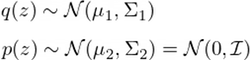

**L2:**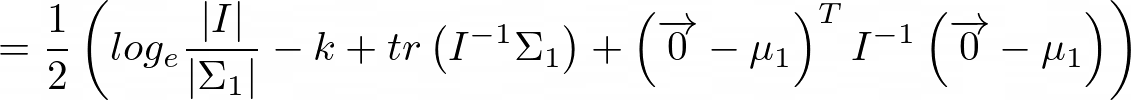

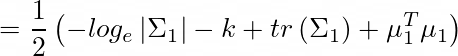

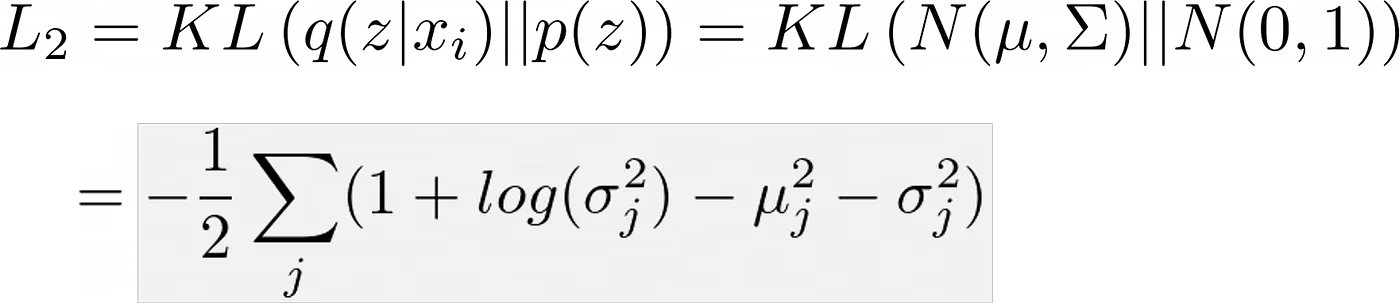

# **if p(z) is not standard normal distribution: p(z)!=N(0,I)**
## **see the kl function: if other is not None**

In [ ]:
class DiagonalGaussianDistribution(object):

    def __init__(self,parameters,deterministics=False):
        self.parameters=parameters
        self.mean, self.logvar=torch.chunk(parameters,2,dim=1) #mu,log(σ^2)
        self.logvar=torch.clamp(self.logvar,min=-30.0,max=20.0)
        self.deterministics=deterministics
        self.var=torch.exp(self.logvar) #σ^2
        self.std=torch.exp(0.5 * self.logvar) #σ
        if self.deterministics:
           self.var=self.std =torch.zeros_like(
               self.mean,device=self.parameters.device, dtype=self.parameters.dtype
           )
    def sample(self,generator=None): #add noise
        noise=randn_tensor(
            self.mean.shape,
            generator,
            self.parameters.device,
            self.parameters.dtype
        )
        x =self.mean + self.std * noise
        return x

    def kl(self,other:"DiagonalGaussianDistribution"=None):
        if self.deterministics:
            return torch.tensor([0.0])
        else:
            if other is None:
                return 0.5 * torch.sum(
                    torch.pow(self.mean,2) + self.var - 1.0 - self.logvar,
                    dim=[1,2,3]
                )
            else:
                return 0.5 * torch.sum(
                    torch.pow(self.mean-other.mean,2)/other.var
                    + self.var/ other.var
                    -1.0
                    -self.logvar
                    +other.logvar,
                    dim=[1,2,3]
                )




In [ ]:
#Autoencoder using KL loss to encode images into latents and decode latens into image

class AVE_KL(nn.Module):

    def __init__(self,
            in_channels=3,
            out_channels=3,
            block_out_channels=(64,),
            layers_per_block=1,
            #activation= silu
            latent_channels=4,
            norm_group_num=32,
            sample_size=32,
            scaling_factor=0.18215,
            shift_factor=None,
            latens_mean=None,
            latens_std=None,
            force_upcast=True,
            use_quant_conv=True,
            use_post_quant_conv=True


                 ):
        super().__init__()

        self.encoder=Encoder(
            in_channels=in_channels,
            out_channels=latent_channels,
            block_out_channels=block_out_channels,
            layers_per_block=layers_per_block,
            norm_group_num=norm_group_num,
            double_z=True


        )

        self.decoder=Decoder(
            in_channels=latent_channels,
            out_channels=out_channels,
            block_out_channels=block_out_channels,
            layers_per_block=layers_per_block,
            norm_group_num=norm_group_num


        )

        self.quant_conv=nn.Conv2d(
            in_channels=2 * latent_channels,
            out_channels=2 * latent_channels,
            stride=1
        ) if use_quant_conv else None

        self.post_quant_conv=nn.Conv2d(
            in_channels=latent_channels,
            out_channels=latent_channels,
            stride=1


        ) if use_post_quant_conv else None

    def _encode(self,x):
        enc=self.encoder(x)

        if self.use_quant_conv is not None:
           enc=self.quant_conv(enc)
        return enc

    def encode(self,x):
        h=self._encode(x)
        posterior=DiagonalGaussianDistribution(h)
        return (posterior,)

    def _decode(self,z):
        if self.post_quant_conv is not None:
            z=self.post_quant_conv(z)
        dec=self.decoder(z)
        return (dec,)

    def decode(self,z,generator=None):









